In [ ]:
# Cài đặt thư viện chia data
!pip install split-folders -q

import splitfolders
import os
from google.colab import drive

# 1. Ép kết nối lại Google Drive một cách mạnh mẽ
print("Đang kết nối lại Google Drive...")
drive.mount('/content/drive', force_remount=True)

zip_path = "/content/drive/MyDrive/PBL5/dataset.zip"

# 2. Kiểm tra xem file có tồn tại không trước khi làm việc
if not os.path.exists(zip_path):
    print("❌ LỖI: Không tìm thấy file dataset.zip tại đường dẫn:", zip_path)
else:
    print("✅ Đã tìm thấy file zip! Đang tiến hành copy và giải nén...")

    # Xóa file/thư mục cũ nếu có để tránh đụng độ
    !rm -rf /content/dataset.zip /content/dataset_raw /content/dataset_split

    # Copy file zip từ Drive sang ổ cứng cục bộ Colab VÀ ĐỔI TÊN thành dataset.zip
    !cp "{zip_path}" "/content/dataset.zip"

    # Giải nén
    !unzip -q "/content/dataset.zip" -d "/content/dataset_raw"

    # TỰ ĐỘNG DÒ TÌM THƯ MỤC GỐC (Tránh trường hợp nén cả thư mục mẹ)
    input_folder = "/content/dataset_raw"
    folder_list = os.listdir(input_folder)
    if len(folder_list) == 1 and os.path.isdir(os.path.join(input_folder, folder_list[0])):
        input_folder = os.path.join(input_folder, folder_list[0])

    # 3. Chia dataset thành 3 tập: Train (70%), Valid (15%), Test (15%)
    output_folder = "/content/dataset_split"

    print(f"Bắt đầu chia Dataset từ nguồn: {input_folder} ...")
    splitfolders.ratio(input_folder, output=output_folder, seed=42, ratio=(0.7, 0.15, 0.15), group_prefix=None)

    print("🎉 Chia data thành công! Dữ liệu đã sẵn sàng tại: /content/dataset_split")

Đang kết nối lại Google Drive...
Mounted at /content/drive
✅ Đã tìm thấy file zip! Đang tiến hành copy và giải nén...
dataset/VietQuat/tải xuống.jpg:  mismatching "local" filename (dataset/VietQuat/tс║гi xuс╗Сng.jpg),
         continuing with "central" filename version
Bắt đầu chia Dataset từ nguồn: /content/dataset_raw/dataset ...


Copying files: 2931 files [00:33, 86.45 files/s] 

🎉 Chia data thành công! Dữ liệu đã sẵn sàng tại: /content/dataset_split


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Cấu hình kích thước ảnh và batch size
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

# Đường dẫn tới 3 tập data vừa chia
train_dir = '/content/dataset_split/train'
val_dir = '/content/dataset_split/val'
test_dir = '/content/dataset_split/test'

# Chỉ Augmentation trên tập Train
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.1,
    brightness_range=[0.8, 1.2]
)

# Tập Valid và Test KHÔNG Augmentation, chỉ chuẩn hóa (rescale)
test_datagen = ImageDataGenerator(rescale=1./255)

# Load data vào
print("--- TẬP TRAIN ---")
train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical')

print("--- TẬP VALIDATION ---")
val_generator = test_datagen.flow_from_directory(
    val_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical')

print("--- TẬP TEST ---")

test_generator = test_datagen.flow_from_directory(
    test_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)

--- TẬP TRAIN ---
Found 2049 images belonging to 4 classes.
--- TẬP VALIDATION ---
Found 438 images belonging to 4 classes.
--- TẬP TEST ---
Found 443 images belonging to 4 classes.


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, ReLU
from tensorflow.keras.optimizers import Adam
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# 1. Tính class_weight (xử lý mất cân bằng nếu có)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
train_class_weights = dict(enumerate(class_weights))
print("Trọng số cân bằng các class:", train_class_weights)

# 2. Xây dựng mô hình CNN (đúng thứ tự)
model = Sequential()

# Block 1
model.add(Conv2D(32, (3, 3), padding='same', use_bias=False, input_shape=(128, 128, 3)))
model.add(BatchNormalization())
model.add(ReLU())
model.add(MaxPooling2D(pool_size=(2, 2)))

# Block 2
model.add(Conv2D(64, (3, 3), padding='same', use_bias=False))
model.add(BatchNormalization())
model.add(ReLU())
model.add(MaxPooling2D(pool_size=(2, 2)))

# Block 3
model.add(Conv2D(128, (3, 3), padding='same', use_bias=False))
model.add(BatchNormalization())
model.add(ReLU())
model.add(MaxPooling2D(pool_size=(2, 2)))

# Flatten và Fully Connected
model.add(Flatten())
model.add(Dense(128, use_bias=False))
model.add(BatchNormalization())
model.add(ReLU())
model.add(Dropout(0.4))

# Output layer (num_classes = 4)
num_classes = len(train_generator.class_indices)
model.add(Dense(num_classes, activation='softmax'))

# 3. Compile
optimizer = Adam(learning_rate=0.0005)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# 4. Tóm tắt mô hình
model.summary()

Trọng số cân bằng các class: {0: np.float64(0.9468576709796673), 1: np.float64(0.9381868131868132), 2: np.float64(1.0518480492813143), 3: np.float64(1.078421052631579)}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,289,252 (16.36 MB)

 Trainable params: 4,288,548 (16.36 MB)

 Non-trainable params: 704 (2.75 KB)

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint
import matplotlib.pyplot as plt


checkpoint_path = '/content/drive/MyDrive/PBL5/fruit_classifier_best2.h5'
checkpoint = ModelCheckpoint(checkpoint_path, monitor='val_accuracy', verbose=1, save_best_only=True, mode='max')

# Bắt đầu Train
epochs = 50
history = model.fit(
    train_generator,
    epochs=epochs,
    validation_data=val_generator,
    class_weight=train_class_weights,
    callbacks=[checkpoint]
)



Epoch 1/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3864 - loss: 1.5608
Epoch 1: val_accuracy improved from None to 0.26256, saving model to /content/drive/MyDrive/PBL5/fruit_classifier_best2.h5



Epoch 1: finished saving model to /content/drive/MyDrive/PBL5/fruit_classifier_best2.h5
65/65 ━━━━━━━━━━━━━━━━━━━━ 161s 2s/step - accuracy: 0.4324 - loss: 1.3758 - val_accuracy: 0.2626 - val_loss: 1.6207
Epoch 2/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5174 - loss: 1.1594
Epoch 2: val_accuracy improved from 0.26256 to 0.27626, saving model to /content/drive/MyDrive/PBL5/fruit_classifier_best2.h5



Epoch 2: finished saving model to /content/drive/MyDrive/PBL5/fruit_classifier_best2.h5
65/65 ━━━━━━━━━━━━━━━━━━━━ 140s 2s/step - accuracy: 0.5339 - loss: 1.0897 - val_accuracy: 0.2763 - val_loss: 1.5443
Epoch 3/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5645 - loss: 0.9938
Epoch 3: val_accuracy improved from 0.27626 to 0.39726, saving model to /content/drive/MyDrive/PBL5/fruit_classifier_best2.h5



Epoch 3: finished saving model to /content/drive/MyDrive/PBL5/fruit_classifier_best2.h5
65/65 ━━━━━━━━━━━━━━━━━━━━ 133s 2s/step - accuracy: 0.5700 - loss: 0.9799 - val_accuracy: 0.3973 - val_loss: 1.5180
Epoch 4/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6217 - loss: 0.8914
Epoch 4: val_accuracy did not improve from 0.39726
65/65 ━━━━━━━━━━━━━━━━━━━━ 132s 2s/step - accuracy: 0.6159 - loss: 0.8885 - val_accuracy: 0.3607 - val_loss: 2.0029
Epoch 5/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6646 - loss: 0.8360
Epoch 5: val_accuracy improved from 0.39726 to 0.45434, saving model to /content/drive/MyDrive/PBL5/fruit_classifier_best2.h5



Epoch 5: finished saving model to /content/drive/MyDrive/PBL5/fruit_classifier_best2.h5
65/65 ━━━━━━━━━━━━━━━━━━━━ 126s 2s/step - accuracy: 0.6496 - loss: 0.8460 - val_accuracy: 0.4543 - val_loss: 1.2888
Epoch 6/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7039 - loss: 0.7318
Epoch 6: val_accuracy improved from 0.45434 to 0.53653, saving model to /content/drive/MyDrive/PBL5/fruit_classifier_best2.h5


...


Epoch 16: finished saving model to /content/drive/MyDrive/PBL5/fruit_classifier_best2.h5
65/65 ━━━━━━━━━━━━━━━━━━━━ 126s 2s/step - accuracy: 0.8102 - loss: 0.4757 - val_accuracy: 0.8402 - val_loss: 0.4408
Epoch 17/50
64/65 ━━━━━━━━━━━━━━━━━━━━ 1s 2s/step - accuracy: 0.8259 - loss: 0.4410
Epoch 17: val_accuracy did not improve from 0.84018
65/65 ━━━━━━━━━━━━━━━━━━━━ 126s 2s/step - accuracy: 0.8214 - loss: 0.4472 - val_accuracy: 0.7123 - val_loss: 0.9053
Epoch 18/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8001 - loss: 0.4656
Epoch 18: val_accuracy did not improve from 0.84018
65/65 ━━━━━━━━━━━━━━━━━━━━ 133s 2s/step - accuracy: 0.8116 - loss: 0.4556 - val_accuracy: 0.8105 - val_loss: 0.4747
Epoch 19/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8317 - loss: 0.4266
Epoch 19: val_accuracy did not improve from 0.84018
65/65 ━━━━━━━━━━━━━━━━━━━━ 127s 2s/step - accuracy: 0.8253 - loss: 0.4334 - val_accuracy: 0.8082 - val_loss: 0.4303
Epoch 20/50
65/65 ━━━━━━━━━━━━━━━━━━━━


Epoch 29: finished saving model to /content/drive/MyDrive/PBL5/fruit_classifier_best2.h5
65/65 ━━━━━━━━━━━━━━━━━━━━ 131s 2s/step - accuracy: 0.8619 - loss: 0.3498 - val_accuracy: 0.8630 - val_loss: 0.3818
Epoch 30/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8667 - loss: 0.3253
Epoch 30: val_accuracy did not improve from 0.86301
65/65 ━━━━━━━━━━━━━━━━━━━━ 150s 2s/step - accuracy: 0.8648 - loss: 0.3286 - val_accuracy: 0.8470 - val_loss: 0.3596
Epoch 31/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8465 - loss: 0.3926
Epoch 31: val_accuracy did not improve from 0.86301
65/65 ━━━━━━━━━━━━━━━━━━━━ 141s 2s/step - accuracy: 0.8477 - loss: 0.3804 - val_accuracy: 0.8082 - val_loss: 0.4805
Epoch 32/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8578 - loss: 0.3500
Epoch 32: val_accuracy did not improve from 0.86301
65/65 ━━━━━━━━━━━━━━━━━━━━ 143s 2s/step - accuracy: 0.8624 - loss: 0.3368 - val_accuracy: 0.8425 - val_loss: 0.4161
Epoch 33/50
65/65 ━━━━━━━━━━━━━━━━━━━━


Epoch 33: finished saving model to /content/drive/MyDrive/PBL5/fruit_classifier_best2.h5
65/65 ━━━━━━━━━━━━━━━━━━━━ 132s 2s/step - accuracy: 0.8712 - loss: 0.3273 - val_accuracy: 0.8676 - val_loss: 0.3649
Epoch 34/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8718 - loss: 0.3224
Epoch 34: val_accuracy did not improve from 0.86758
65/65 ━━━━━━━━━━━━━━━━━━━━ 128s 2s/step - accuracy: 0.8687 - loss: 0.3391 - val_accuracy: 0.8311 - val_loss: 0.4857
Epoch 35/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8807 - loss: 0.3085
Epoch 35: val_accuracy did not improve from 0.86758
65/65 ━━━━━━━━━━━━━━━━━━━━ 126s 2s/step - accuracy: 0.8819 - loss: 0.3038 - val_accuracy: 0.8676 - val_loss: 0.3322
Epoch 36/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8790 - loss: 0.3284
Epoch 36: val_accuracy did not improve from 0.86758
65/65 ━━━━━━━━━━━━━━━━━━━━ 127s 2s/step - accuracy: 0.8853 - loss: 0.3107 - val_accuracy: 0.8470 - val_loss: 0.3785
Epoch 37/50
65/65 ━━━━━━━━━━━━━━━━━━━━


Epoch 39: finished saving model to /content/drive/MyDrive/PBL5/fruit_classifier_best2.h5
65/65 ━━━━━━━━━━━━━━━━━━━━ 127s 2s/step - accuracy: 0.8834 - loss: 0.2993 - val_accuracy: 0.8699 - val_loss: 0.3708
Epoch 40/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8970 - loss: 0.2759
Epoch 40: val_accuracy did not improve from 0.86986
65/65 ━━━━━━━━━━━━━━━━━━━━ 144s 2s/step - accuracy: 0.8873 - loss: 0.2890 - val_accuracy: 0.8607 - val_loss: 0.3945
Epoch 41/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8871 - loss: 0.2909
Epoch 41: val_accuracy improved from 0.86986 to 0.89041, saving model to /content/drive/MyDrive/PBL5/fruit_classifier_best2.h5



Epoch 41: finished saving model to /content/drive/MyDrive/PBL5/fruit_classifier_best2.h5
65/65 ━━━━━━━━━━━━━━━━━━━━ 136s 2s/step - accuracy: 0.8931 - loss: 0.2782 - val_accuracy: 0.8904 - val_loss: 0.3439
Epoch 42/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8828 - loss: 0.2872
Epoch 42: val_accuracy did not improve from 0.89041
65/65 ━━━━━━━━━━━━━━━━━━━━ 124s 2s/step - accuracy: 0.8873 - loss: 0.2842 - val_accuracy: 0.8470 - val_loss: 0.3958
Epoch 43/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8957 - loss: 0.2684
Epoch 43: val_accuracy did not improve from 0.89041
65/65 ━━━━━━━━━━━━━━━━━━━━ 131s 2s/step - accuracy: 0.8965 - loss: 0.2724 - val_accuracy: 0.8128 - val_loss: 0.5224
Epoch 44/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8870 - loss: 0.3131
Epoch 44: val_accuracy did not improve from 0.89041
65/65 ━━━━━━━━━━━━━━━━━━━━ 124s 2s/step - accuracy: 0.8995 - loss: 0.2844 - val_accuracy: 0.8562 - val_loss: 0.3772
Epoch 45/50
65/65 ━━━━━━━━━━━━━━━━━━━━

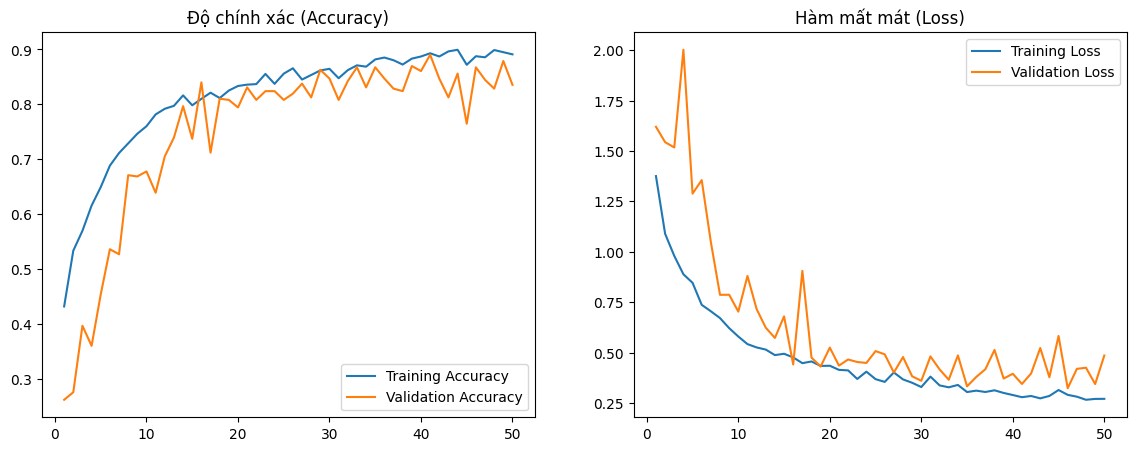

In [ ]:
# Vẽ biểu đồ
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Độ chính xác (Accuracy)')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Hàm mất mát (Loss)')
plt.show()

In [ ]:
from tensorflow.keras.models import load_model

# Tải lại
best_model = load_model(checkpoint_path)

print("Đang đánh giá mô hình trên tập bài thi (Test Set)...")
test_loss, test_acc = best_model.evaluate(test_generator)

print(f"\n====================================")
print(f"ĐIỂM THI TỐT NGHIỆP CỦA MODEL:")
print(f"Độ chính xác (Test Accuracy): {test_acc * 100:.2f}%")
print(f"====================================")

Đang đánh giá mô hình trên tập bài thi (Test Set)...
14/14 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step - accuracy: 0.9278 - loss: 0.2531

ĐIỂM THI TỐT NGHIỆP CỦA MODEL:
Độ chính xác (Test Accuracy): 92.78%


Đang tải não bộ AI...


Tải thành công! Đã sẵn sàng nhận diện.

👇 HÃY CHỌN 1 BỨC ẢNH TRÁI CÂY TỪ MÁY TÍNH CỦA BẠN 👇


Saving 1776917240172-a4f2353c-a607-483c-83ef-fe15ce888a71.jpg to 1776917240172-a4f2353c-a607-483c-83ef-fe15ce888a71.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 620ms/step


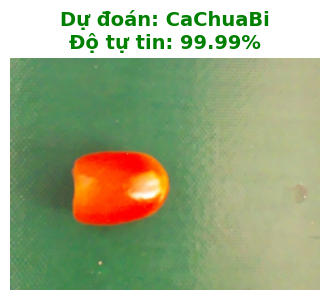


--- CHI TIẾT TỶ LỆ DỰ ĐOÁN ---
- CaChuaBi: 99.99%
- DauTay: 0.01%
- Nho: 0.00%
- VietQuat: 0.00%


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from google.colab import files
from IPython.display import Image, display
from google.colab import drive


# 1. Tải lại model xịn nhất của bạn từ Google Drive
# drive.mount('/content/drive', force_remount=True)
model_path = '/content/drive/MyDrive/PBL5/fruit_classifier_best1.h5'
print("Đang tải não bộ AI...")
model = load_model(model_path)
print("Tải thành công! Đã sẵn sàng nhận diện.")

# 2. Định nghĩa tên các class (LƯU Ý QUAN TRỌNG TẠI ĐÂY)
# Hàm flow_from_directory mặc định sẽ sắp xếp tên thư mục theo bảng chữ cái A-Z
# Nếu 4 thư mục của bạn tên CHÍNH XÁC là: CaChuaBi, DauTay, Nho, VietQuat
# thì thứ tự đúng sẽ là như list bên dưới. (Nếu bạn đặt tên khác thì nhớ sửa lại cho đúng thứ tự A-Z nhé!)
class_labels = ['CaChuaBi', 'DauTay', 'Nho', 'VietQuat']

# 3. Hiện nút Upload ảnh từ máy tính
print("\n👇 HÃY CHỌN 1 BỨC ẢNH TRÁI CÂY TỪ MÁY TÍNH CỦA BẠN 👇")
uploaded = files.upload()

for fn in uploaded.keys():
  # Đường dẫn tới file vừa upload
  path = '/content/' + fn

  # 4. Tiền xử lý ảnh (Phải y hệt như lúc Train)
  # - Đưa về kích thước 128x128
  img = image.load_img(path, target_size=(128, 128))

  # - Chuyển thành mảng ma trận
  img_array = image.img_to_array(img)

  # - Thêm 1 chiều đại diện cho batch (từ 128,128,3 thành 1,128,128,3)
  img_array = np.expand_dims(img_array, axis=0)

  # - Chuẩn hóa (chia 255.0 giống hệt thông số rescale lúc nãy)
  img_array /= 255.0

  # 5. Đưa vào Model để dự đoán
  predictions = model.predict(img_array)

  # Lấy ra class có tỷ lệ phần trăm cao nhất
  predicted_class_index = np.argmax(predictions[0])
  predicted_class_name = class_labels[predicted_class_index]
  confidence = predictions[0][predicted_class_index] * 100

  # 6. Trình bày kết quả thật đẹp mắt
  plt.figure(figsize=(4, 4))
  # Đọc lại ảnh gốc để hiển thị cho nét (không bị mờ do resize)
  original_img = image.load_img(path)
  plt.imshow(original_img)
  plt.axis('off') # Tắt mấy cái trục tọa độ đi cho đẹp

  # In kết quả lên tiêu đề ảnh
  title = f'Dự đoán: {predicted_class_name}\nĐộ tự tin: {confidence:.2f}%'

  # Chỉnh màu chữ: Tự tin trên 80% in màu xanh lá, dưới thì in màu cam cảnh báo
  text_color = 'green' if confidence >= 80 else 'orange'
  plt.title(title, color=text_color, fontsize=14, fontweight='bold')

  plt.show()

  # In chi tiết các chỉ số ra text để xem thêm
  print("\n--- CHI TIẾT TỶ LỆ DỰ ĐOÁN ---")
  for i, label in enumerate(class_labels):
      print(f"- {label}: {predictions[0][i]*100:.2f}%")